In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from mne.decoding import cross_val_multiscore
from mne.decoding import SlidingEstimator
from mne.preprocessing import ICA

# --- PATHS ---
basic_path = 'project/ds006761'
subject_id = 'sub-01'
bdf_file = f'{basic_path}/{subject_id}/eeg/{subject_id}_task-RPS_eeg.bdf'
events_file = f'{basic_path}/{subject_id}/eeg/{subject_id}_task-RPS_events.tsv'

print(f"Ready to process {subject_id}")

Ready to process sub-01


In [ ]:
# Load the raw BDF file
raw = mne.io.read_raw_bdf(bdf_file, preload=True)

# Select Channels: BioSemi 64 usually uses channels 0-63 for EEG
picks = list(range(0, 64))

Extracting EDF parameters from /Users/abijithlakshmanan/Desktop/Sem 3/EEG/EEG_PROJECT/project/ds006761/sub-01/eeg/sub-01_task-RPS_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...


In [ ]:
# --- 3. PRE-PROCESSING ---

# A. Filtering
# 1. Notch Filter (Remove 50Hz Line Noise)
raw.notch_filter(np.arange(50, 251, 50), picks=picks, filter_length='auto', phase='zero')

# 2. Main Filter (0.1 - 30 Hz)
raw.filter(l_freq=0.1, h_freq=30, picks=picks) 

# B. Re-reference (Common Average Reference)
raw.set_eeg_reference('average', projection=False)

print("Pre-processing complete: Notch, Band-Pass (0.1-30Hz), and Re-referencing only.")

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13517 samples (6.600 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   11.3s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:   44.0s finished


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 67585 samples (33.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   14.1s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:   53.4s finished


Fitting ICA...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 6759 samples (3.300 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   10.6s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:   35.6s finished


Fitting ICA to data using 64 channels (please be patient, this may take a while)


/var/folders/6m/w03l77fd491bvp8vjs060n780000gn/T/ipykernel_41981/1942912699.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_for_ica, picks=picks)


Selecting by number: 20 components
Fitting ICA took 606.0s.
Applying ICA cleaning to original data...
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 64 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | sub-01_task-RPS_eeg.bdf, 143 x 7514112 (3669.0 s), ~8.01 GB, data loaded>

In [ ]:
# Read the events TSV file
events_df = pd.read_csv(events_file, sep='\t')

# Convert event times from seconds to samples
sfreq = raw.info['sfreq']
onsets = events_df['onset'].values
onsets_samples = (onsets * sfreq).astype(int)

# Extract labels (1=Rock, 2=Paper, 3=Scissors)
labels = events_df['player1_resp'].values.astype(int)

# Create the MNE events array: [Sample_Index, 0, Event_ID]
events = np.column_stack((onsets_samples, np.zeros_like(onsets_samples), labels))

# Filter to keep only valid game trials (labels 1, 2, or 3)
valid_indices = np.isin(events[:, 2], [1, 2, 3])
events = events[valid_indices]

print(f"Events created: {len(events)} valid trials found.")

Events created: 480 valid trials found.


In [ ]:
# Define epoch parameters
tmin, tmax = -0.2, 2.0

# Define rejection criteria
reject_criteria = dict(eeg=300e-6) 

# Create Epochs
epochs = mne.Epochs(raw, events, event_id=None, tmin=tmin, tmax=tmax, 
                    baseline=(-0.2, 0),       
                    picks=picks, 
                    reject=reject_criteria,   # Set to None for now
                    preload=True, 
                    verbose=True)


print(f"Epoching complete. Final trial count: {len(epochs)}")

if len(epochs) > 0:
    # Resample to 256Hz (Speed up computation)
    epochs.resample(256)
    

else:
    print("CRITICAL WARNING: Epochs are still empty. Check your event codes or data path.")

Not setting metadata
480 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 4507 original time points ...
    Rejecting  epoch based on EEG : ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10', '1-A11', '1-A12', '1-A13', '1-A14', '1-A15', '1-A16', '1-A17', '1-A18', '1-A19', '1-A20', '1-A21', '1-A22', '1-A23', '1-A24', '1-A25', '1-A26', '1-A27', '1-A28', '1-A29', '1-A30', '1-A31', '1-A32', '1-B1', '1-B2', '1-B3', '1-B4', '1-B5', '1-B6', '1-B7', '1-B8', '1-B9', '1-B10', '1-B11', '1-B12', '1-B13', '1-B14', '1-B15', '1-B16', '1-B17', '1-B18', '1-B19', '1-B20', '1-B21', '1-B22', '1-B23', '1-B24', '1-B25', '1-B26', '1-B27', '1-B28', '1-B29', '1-B30', '1-B31', '1-B32']
    Rejecting  epoch based on EEG : ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10', '1-A11', '1-A12', '1-A13', '1-A14', '1-A15', '1-A16', '1-A17', '1-A18', '1-A19', '1-A20', 

/var/folders/6m/w03l77fd491bvp8vjs060n780000gn/T/ipykernel_41981/2283186530.py:10: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(raw, events, event_id=None, tmin=tmin, tmax=tmax,


In [31]:
def create_pseudo_trials(X, y, n_avg=4):
    """
    Averages every n_avg trials of the same class to create 'pseudo-trials'.
    This increases SNR (Signal-to-Noise Ratio).
    """
    unique_classes = np.unique(y)
    X_pseudo, y_pseudo = [], []

    for cls in unique_classes:
        # Find all trials belonging to this class
        indices = np.where(y == cls)[0]
        np.random.shuffle(indices)
        
        # Truncate to make divisible by n_avg
        n_keep = len(indices) - (len(indices) % n_avg)
        indices = indices[:n_keep]
        
        # Average the groups
        cls_data = X[indices]
        cls_data_avg = cls_data.reshape(-1, n_avg, *cls_data.shape[1:]).mean(axis=1)
        
        X_pseudo.append(cls_data_avg)
        y_pseudo.extend([cls] * len(cls_data_avg))
        
    return np.vstack(X_pseudo), np.array(y_pseudo)

# Extract data from epochs
X = epochs.get_data()
y = epochs.events[:, -1]

# Create pseudo-trials
if len(y) > 0:
    X_ps, y_ps = create_pseudo_trials(X, y, n_avg=4)
    print(f"Pseudo-trials created. Shape: {X_ps.shape}")
else:
    print("Error: No trials left after rejection! Check your reject_criteria.")

Error: No trials left after rejection! Check your reject_criteria.


/var/folders/6m/w03l77fd491bvp8vjs060n780000gn/T/ipykernel_41981/4134147846.py:28: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  X = epochs.get_data()


In [29]:
# Define the Classifier: Scalar + SVM (Linear kernel)
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True))

# Define Cross-Validation: 10-fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define Sliding Estimator (decodes at every time point)
slider = SlidingEstimator(clf, scoring='accuracy', n_jobs=1)

print("Running decoding... this may take a moment.")
scores = cross_val_multiscore(slider, X_ps, y_ps, cv=cv, n_jobs=1)

# Average scores across all CV folds
mean_scores = np.mean(scores, axis=0)
print("Decoding complete.")

Running decoding... this may take a moment.


100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  109.01it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   87.96it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  103.06it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   84.03it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:07<00:00,   79.29it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:07<00:00,   75.61it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   85.99it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   82.64it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:07<00:00,   78.89it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:07<00:00,   78.89it/s]


Decoding complete.


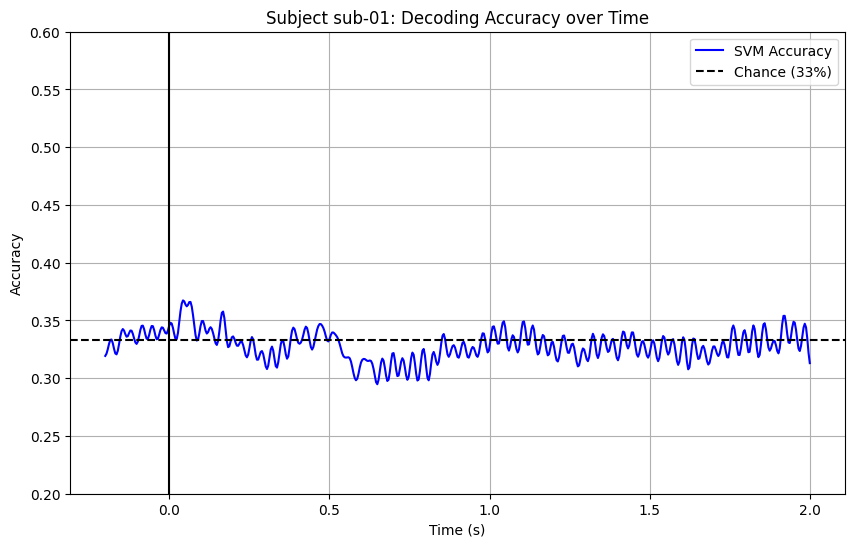

In [ ]:
# --- 8. PLOTTING ---

time_points = np.linspace(tmin, tmax, len(mean_scores))

# Smooth the data for better visualization
smoothed_scores = gaussian_filter1d(mean_scores, sigma=2)

plt.figure(figsize=(10, 6))
plt.plot(time_points, smoothed_scores, label='SVM Accuracy', color='blue')
plt.axhline(1/3, color='k', linestyle='--', label='Chance (33%)')
plt.axvline(0, color='k', linestyle='-')
plt.ylim(0.2, 0.6) 
plt.title(f'Subject {subject_id}: Decoding Accuracy over Time')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()